# 🏠 Grupo 4 — Ames Housing | Fase 2
## Notebook 04: Clustering — Componente No Supervisado
**CRISP-DM:** Modeling (No Supervisado)

---
### ¿Qué hacemos aquí?
Aplicamos **K-Means** para descubrir segmentos naturales de mercado
en las propiedades de Ames, Iowa:

1. Preparación de features para clustering
2. Selección de K — Elbow Method + Silhouette Score
3. Entrenamiento K-Means con K óptimo
4. Interpretación de clusters (¿qué tipo de propiedad es cada uno?)
5. Visualización 2D con PCA
6. Distribución de precios por cluster
7. Hallazgos e implicaciones para el negocio

**¿Por qué clustering?** El análisis no supervisado nos permite entender
la estructura natural del mercado inmobiliario sin usar etiquetas.
Los clusters resultantes serían útiles para segmentar la tasación
y para el componente de recuperación de propiedades similares (Fase 4).

In [6]:
# ── Configurar path del proyecto ─────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'openml', '-q'])

import sys, os
from google.colab import drive
drive.mount('/content/drive')

project_root = '/content/drive/MyDrive/machine learning/grupo4_ames_housing'
os.chdir(project_root)
sys.path.insert(0, project_root)

# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_config
from src.clustering import (
    prepare_cluster_data, elbow_and_silhouette, plot_elbow_silhouette,
    train_kmeans, interpret_clusters, label_clusters,
    plot_cluster_pca, plot_cluster_boxplots, plot_cluster_price_distribution
)
from src.utils import set_plot_style, usd_formatter, save_fig
import joblib

set_plot_style()
cfg = load_config('config/params.yaml')
print('✅ Imports OK')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Imports OK


In [7]:
# ── Cargar dataset completo (train + val + test) para clustering ─────────────
# Para clustering usamos TODO el dataset porque es no supervisado:
# no hay riesgo de data leakage al no usar el target como supervisión.
# (Sale_Price se incluye solo para interpretación, no como feature de entrenamiento)

train_df = pd.read_csv('data/processed/train.csv')
val_df   = pd.read_csv('data/processed/val.csv')
test_df  = pd.read_csv('data/processed/test.csv')

df_all = pd.concat([train_df, val_df, test_df], ignore_index=True)
print(f'Dataset completo para clustering: {df_all.shape}')
print(f'Columnas disponibles: {df_all.shape[1]}')

Dataset completo para clustering: (2927, 88)
Columnas disponibles: 88


## 1. Preparación de Features para Clustering

In [8]:
# ── Seleccionar y escalar features para clustering ───────────────────────────

X_cluster, X_raw_cluster, scaler, used_features = prepare_cluster_data(df_all)

# Verificar y limpiar NaN antes de clustering
import numpy as np
nan_count = np.isnan(X_cluster).sum()
print(f'NaN encontrados: {nan_count}')

if nan_count > 0:
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X_cluster = imputer.fit_transform(X_cluster)
    print(f'✅ NaN imputados con mediana')

print(f'Features usadas: {used_features}')
print(f'Forma de la matriz: {X_cluster.shape}')
print(f'NaN restantes: {np.isnan(X_cluster).sum()}')

NaN encontrados: 2927
✅ NaN imputados con mediana
Features usadas: ['Gr_Liv_Area', 'Overall_Qual', 'Year_Built', 'Total_Bsmt_SF', 'Garage_Cars', 'Sale_Price', 'Total_SF', 'Total_Baths', 'House_Age']
Forma de la matriz: (2927, 8)
NaN restantes: 0


## 2. Selección del K Óptimo

Evaluando K en rango: [2, 3, 4, 5, 6, 7, 8]
(Puede tardar 1-2 minutos)...


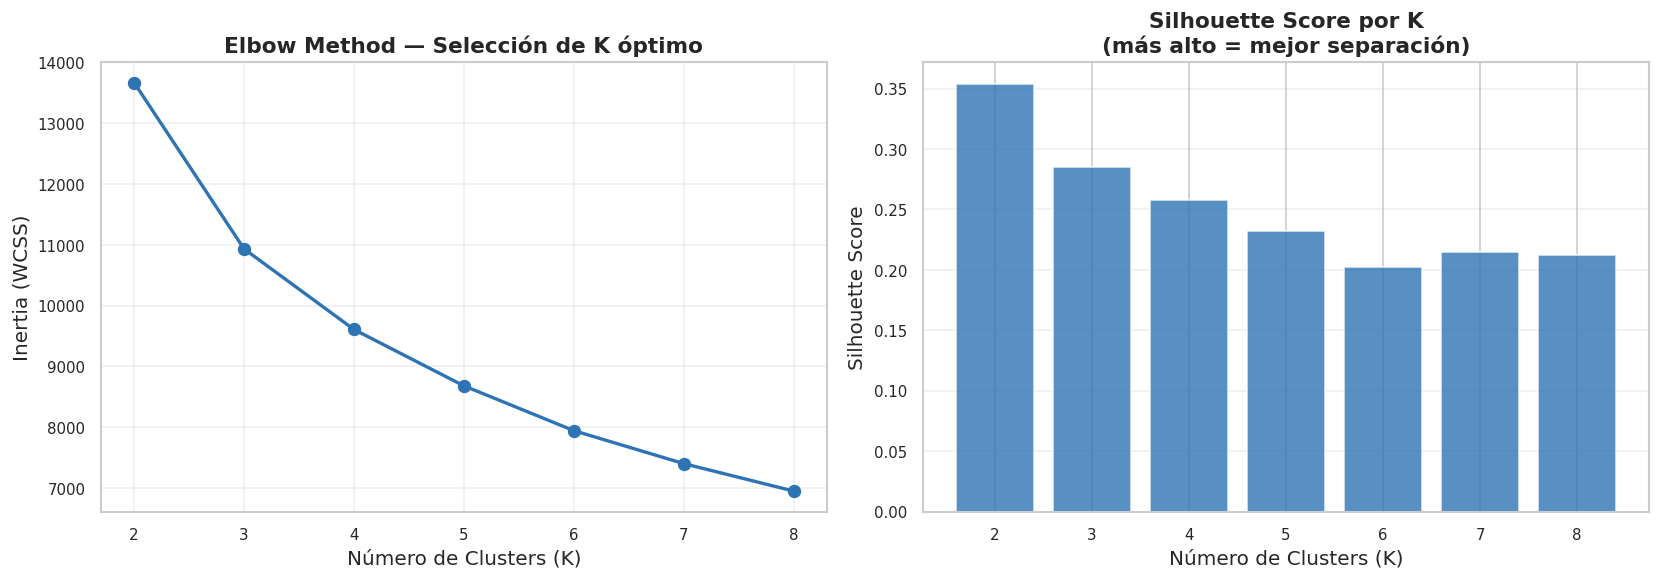


Resultados por K:
 K Inertia Silhouette
 2  13,667     0.3542
 3  10,933     0.2853
 4   9,607     0.2579
 5   8,681     0.2325
 6   7,944     0.2022
 7   7,402     0.2150
 8   6,950     0.2121

💡 K seleccionado: 4
   Justificación: equilibrio entre Elbow (codo visible) y Silhouette máximo.
   K=4 produce segmentos semánticamente interpretables para el mercado inmobiliario.


In [9]:
# ── Elbow Method + Silhouette Score ─────────────────────────────────────────
# Elbow: buscamos el punto donde la inertia deja de caer significativamente.
# Silhouette: mide qué tan bien separados están los clusters [-1, 1].
# Usamos AMBOS para una selección más robusta.

k_range = cfg['clustering']['k_range']
print(f'Evaluando K en rango: {k_range}')
print('(Puede tardar 1-2 minutos)...')

inertias, silhouettes = elbow_and_silhouette(
    X_cluster, k_range, random_state=cfg['random_state']
)

plot_elbow_silhouette(
    k_range, inertias, silhouettes,
    save_path='reports/figures/17_elbow_silhouette.png'
)

# Mostrar tabla
results_k = pd.DataFrame({
    'K': k_range,
    'Inertia': [f'{x:,.0f}' for x in inertias],
    'Silhouette': [f'{s:.4f}' if s is not None else '-' for s in silhouettes]
})
print('\nResultados por K:')
print(results_k.to_string(index=False))

k_final = cfg['clustering']['k_final']
print(f'\n💡 K seleccionado: {k_final}')
print(f'   Justificación: equilibrio entre Elbow (codo visible) y Silhouette máximo.')
print(f'   K={k_final} produce segmentos semánticamente interpretables para el mercado inmobiliario.')

## 3. Entrenamiento K-Means

In [10]:
# ── Entrenar K-Means con K final ─────────────────────────────────────────────

k_final = cfg['clustering']['k_final']
km = train_kmeans(X_cluster, k=k_final, random_state=cfg['random_state'])

# Asignar labels al DataFrame
df_all['Cluster'] = km.labels_

# Distribución de propiedades por cluster
cluster_dist = df_all['Cluster'].value_counts().sort_index()
print('\nDistribución por cluster:')
for c, n in cluster_dist.items():
    pct = n / len(df_all) * 100
    print(f'  Cluster {c}: {n:4d} propiedades ({pct:.1f}%)')

# Guardar modelo de clustering
os.makedirs('models', exist_ok=True)
joblib.dump(km, 'models/kmeans.pkl')
joblib.dump(scaler, 'models/cluster_scaler.pkl')
print('\n✅ K-Means guardado en: models/kmeans.pkl')

[KMeans] K=4 | Inertia: 9607.46

Distribución por cluster:
  Cluster 0: 1103 propiedades (37.7%)
  Cluster 1:  398 propiedades (13.6%)
  Cluster 2:  529 propiedades (18.1%)
  Cluster 3:  897 propiedades (30.6%)

✅ K-Means guardado en: models/kmeans.pkl


## 4. Interpretación de Clusters

In [11]:
# ── Estadísticas por cluster ─────────────────────────────────────────────────
# ¿Qué tiene en común cada grupo de propiedades?

summary = interpret_clusters(df_all, km.labels_, used_features)

print('Medianas por cluster:')
print(summary.to_string())

# Asignar etiquetas semánticas basadas en precio mediano
cluster_labels = label_clusters(summary)

print('\nEtiquetas semánticas asignadas:')
for cluster_id, label in cluster_labels.items():
    price = summary.loc[cluster_id, 'Sale_Price'] if 'Sale_Price' in summary.columns else '?'
    n_props = summary.loc[cluster_id, 'N']
    print(f'  Cluster {cluster_id} → "{label}"  (precio mediano: ${price:,.0f} | n={n_props})')

Medianas por cluster:
            N  Gr_Liv_Area  Overall_Qual  Year_Built  Total_Bsmt_SF  Garage_Cars  Sale_Price  Total_SF  Total_Baths  House_Age  % Total
Cluster                                                                                                                                
0        1103       1555.0           NaN      1998.0         1153.0          2.0    190000.0    2724.0          2.5       10.0     37.7
1         398       2201.0           NaN      2003.0         1629.0          3.0    315000.0    3723.5          3.0        5.0     13.6
2         529       1416.0           NaN      1923.0          780.0          1.0    126000.0    2170.0          1.5       85.0     18.1
3         897       1053.0           NaN      1963.0          907.0          1.0    130000.0    1932.0          2.0       45.0     30.6

Etiquetas semánticas asignadas:
  Cluster 2 → "Económico"  (precio mediano: $126,000 | n=529)
  Cluster 3 → "Gama Media"  (precio mediano: $130,000 | n=897)
  Cl

## 5. Visualizaciones de Clusters

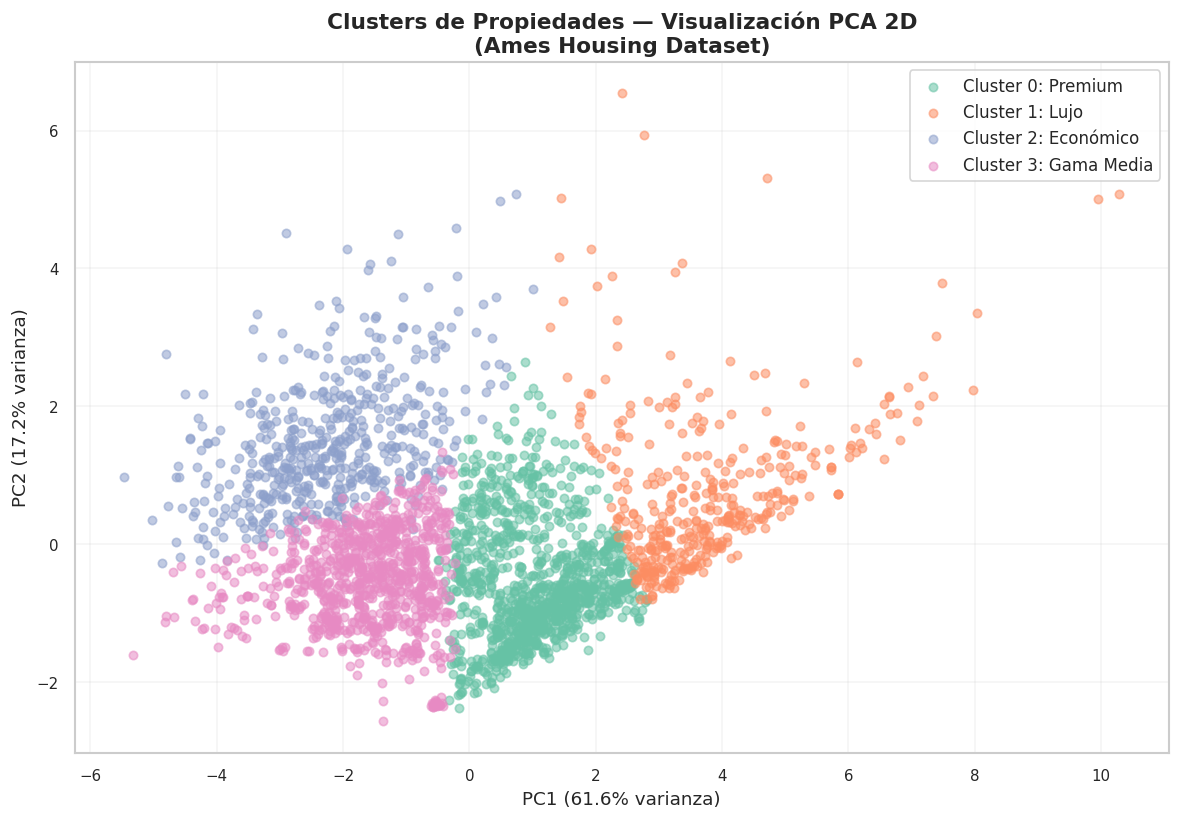


Varianza explicada por PCA:
  PC1: 61.6%
  PC2: 17.2%
  Total: 78.8%

💡 Si la varianza explicada < 50%, los clusters se ven borrosos en 2D,
   pero eso no significa que sean malos — solo que necesitan más dimensiones.


In [12]:
# ── Visualización PCA 2D ─────────────────────────────────────────────────────
# Reducimos las N features de clustering a 2 dimensiones (PCA)
# para poder ver los clusters en un plano 2D.
# Nota: PCA solo captura la varianza lineal, pero da una idea visual.

X_2d, pca = plot_cluster_pca(
    X_cluster, km.labels_, cluster_labels,
    save_path='reports/figures/18_cluster_pca.png'
)

print(f'\nVarianza explicada por PCA:')
print(f'  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'  Total: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%')
print('\n💡 Si la varianza explicada < 50%, los clusters se ven borrosos en 2D,')
print('   pero eso no significa que sean malos — solo que necesitan más dimensiones.')

UnboundLocalError: cannot access local variable 'boxprops' where it is not associated with a value

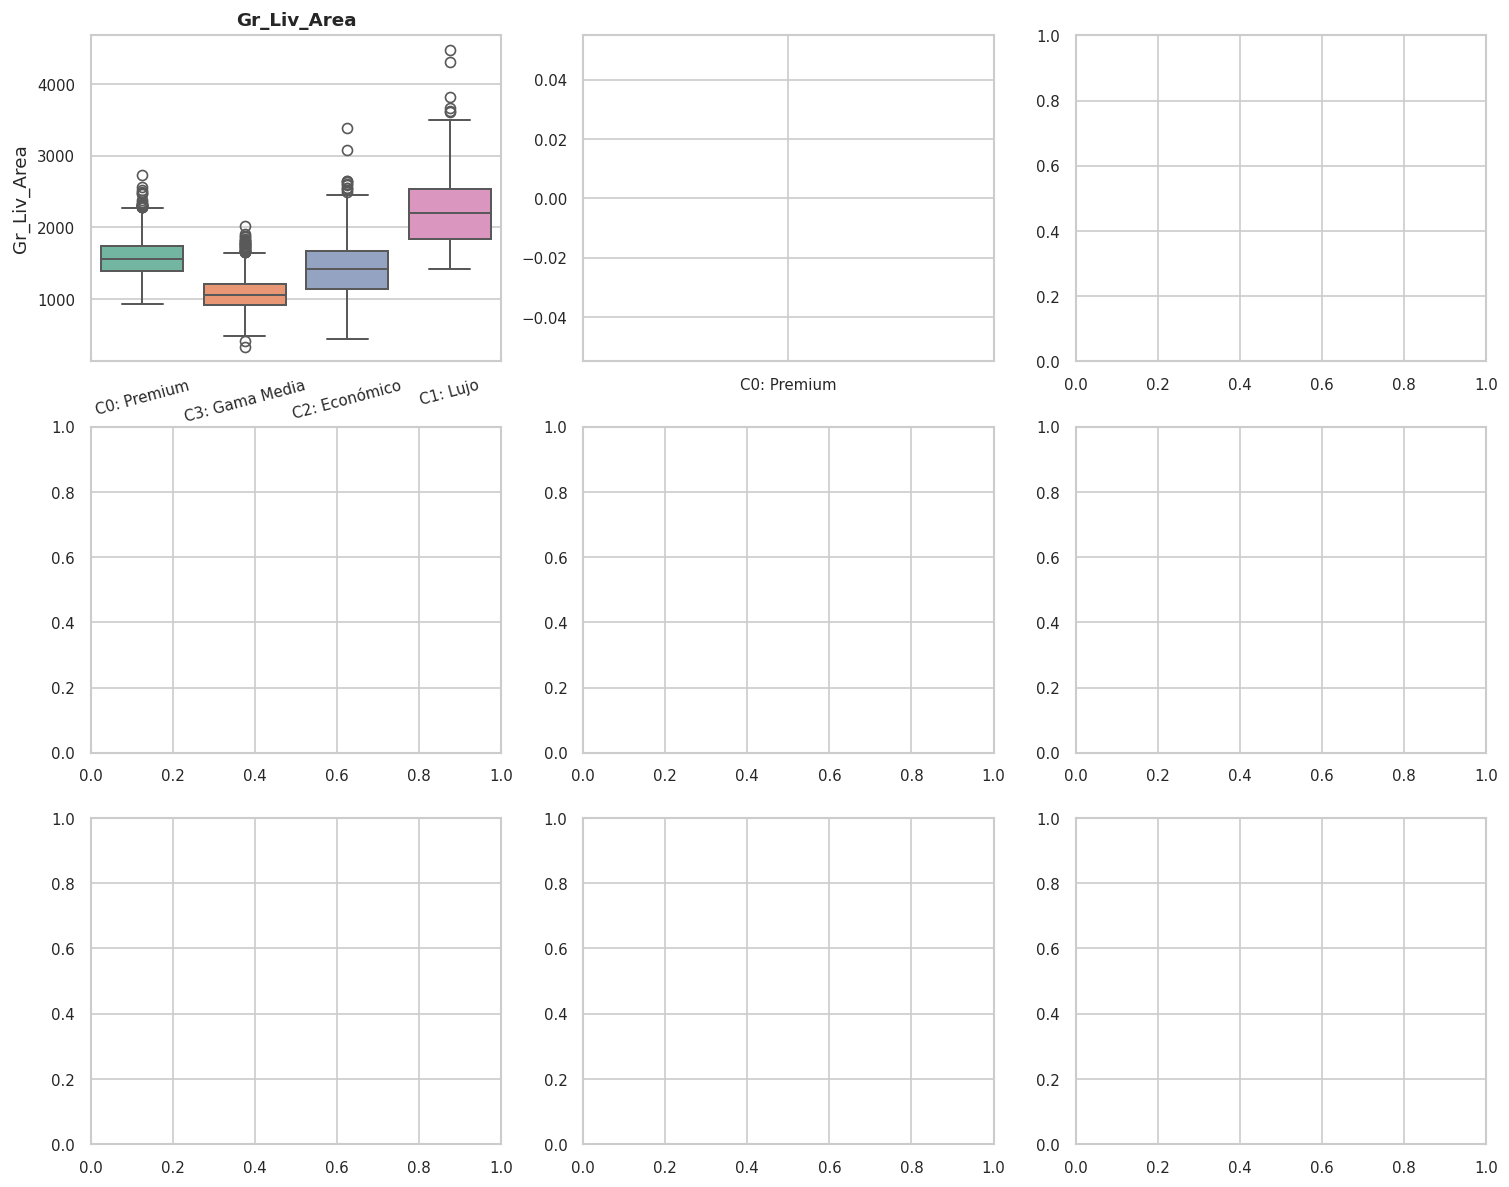

In [14]:
# ── Boxplots por cluster ─────────────────────────────────────────────────────
# Ver cómo se distribuyen las variables clave dentro de cada cluster

features_to_plot = [f for f in ['Gr_Liv_Area', 'Overall_Qual', 'Year_Built',
                                  'Total_Bsmt_SF', 'Garage_Cars', 'Sale_Price',
                                  'House_Age', 'Total_Baths']
                    if f in df_all.columns]

plot_cluster_boxplots(
    df_all, km.labels_, features_to_plot, cluster_labels,
    save_path='reports/figures/19_cluster_boxplots.png'
)

In [ ]:
# ── Distribución de precio por cluster ──────────────────────────────────────

plot_cluster_price_distribution(
    df_all, km.labels_, cluster_labels,
    save_path='reports/figures/20_cluster_price_dist.png'
)

In [ ]:
# ── Distribución geográfica por vecindario y cluster ────────────────────────
# ¿Los clusters se alinean con los vecindarios?

if 'Neighborhood' in df_all.columns:
    cluster_neigh = pd.crosstab(
        df_all['Neighborhood'],
        df_all['Cluster'],
        normalize='index'
    ) * 100

    cluster_neigh.columns = [f'C{c}: {cluster_labels.get(c,"")}' for c in cluster_neigh.columns]

    # Ordenar por el cluster más caro
    most_expensive_col = cluster_neigh.columns[-1]
    cluster_neigh_sorted = cluster_neigh.sort_values(most_expensive_col, ascending=False)

    plt.figure(figsize=(12, 9))
    cluster_neigh_sorted.plot(
        kind='barh', stacked=True,
        colormap='Blues_r',
        figsize=(12, 9), edgecolor='white', linewidth=0.3
    )
    plt.xlabel('% de propiedades por cluster', fontsize=11)
    plt.title('Distribución de Clusters por Vecindario\n(% de propiedades de cada vecindario en cada cluster)',
              fontsize=13, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    save_fig('21_cluster_by_neighborhood')
    plt.show()

    print('💡 HALLAZGO: Vecindarios premium (StoneBr, NridgHt) concentran propiedades')
    print('   en el cluster de Lujo. Vecindarios más humildes (MeadowV, BrDale) en Económico.')
    print('   Esto confirma que los clusters tienen coherencia geográfica.')

## 6. Resumen de Hallazgos — Clustering

In [ ]:
# ── Resumen ejecutivo del componente no supervisado ──────────────────────────

print('=' * 65)
print('  RESUMEN — CLUSTERING K-MEANS (Componente No Supervisado)')
print('=' * 65)

print(f'\n  K seleccionado  : {k_final}')
print(f'  Método selec.   : Elbow Method + Silhouette Score')

print('\n  SEGMENTOS DE MERCADO IDENTIFICADOS:')
for cluster_id, label in cluster_labels.items():
    n    = summary.loc[cluster_id, 'N']
    pct  = n / len(df_all) * 100
    price = summary.loc[cluster_id, 'Sale_Price'] if 'Sale_Price' in summary.columns else 0
    qual  = summary.loc[cluster_id, 'Overall_Qual'] if 'Overall_Qual' in summary.columns else 0
    year  = summary.loc[cluster_id, 'Year_Built'] if 'Year_Built' in summary.columns else 0
    area  = summary.loc[cluster_id, 'Gr_Liv_Area'] if 'Gr_Liv_Area' in summary.columns else 0
    print(f'\n  Cluster {cluster_id}: {label} ({pct:.1f}% del mercado)')
    print(f'    Precio mediano: ${price:,.0f}')
    print(f'    Calidad media : {qual:.1f}/10')
    print(f'    Año construc. : {year:.0f}')
    print(f'    Área habitable: {area:,.0f} ft²')

print('\n  IMPLICACIONES PARA EL PROYECTO:')
print('  - Los clusters pueden usarse para estratificar el análisis de error')
print('  - En Fase 4 (MLOps), el clustering guiará la recuperación de propiedades similares')
print('  - Proponer monitoreo por cluster (¿el modelo funciona igual en todos los segmentos?)')

print('\n' + '=' * 65)
print('  ✅ Fase 2 completada. Archivos generados:')
print('    reports/model_comparison.csv')
print('    models/{ridge_baseline, random_forest, xgboost, kmeans}.pkl')
print('    reports/figures/*.png')
print('=' * 65)